# Discounted Cash Flow Model Implementation  

What is a Discounted Cash Flow Model?

Discounted Cash Flow (DCF) is a valuation method used to esti- mate the value of an investment based on its expected future cash flows:
- Foundational valuation technique in finance
- Based on the time value of money principle
- Estimates intrinsic value rather than market value


In [16]:
# Function to simulate financials and calculate FCF
simulate_financials <- function(initial_revenue, projection_years, growth_rates,
                                ebitda_margins, capex_percent, nwc_percent, tax_rate) {
  revenue <- numeric(projection_years)
  ebitda <- numeric(projection_years)
  depreciation <- numeric(projection_years)
  ebit <- numeric(projection_years)
  tax <- numeric(projection_years)
  nopat <- numeric(projection_years)
  capex <- numeric(projection_years)
  nwc_change <- numeric(projection_years)
  fcf <- numeric(projection_years)
  
  revenue[1] <- initial_revenue * (1 + growth_rates[1])
  
  for (t in 1:projection_years) {
    if (t > 1) revenue[t] <- revenue[t - 1] * (1 + growth_rates[t])
    
    ebitda[t] <- revenue[t] * ebitda_margins[t]
    depreciation[t] <- 0.05 * revenue[t]  # Assume 5% of revenue
    ebit[t] <- ebitda[t] - depreciation[t]
    tax[t] <- ebit[t] * tax_rate
    nopat[t] <- ebit[t] - tax[t]
    capex[t] <- revenue[t] * capex_percent[t]
    nwc_change[t] <- revenue[t] * nwc_percent[t]
    fcf[t] <- nopat[t] + depreciation[t] - capex[t] - nwc_change[t]
  }
  
  return(fcf)
}

In [18]:
# Function to perform DCF valuation
dcf_valuation <- function(fcf, discount_rate, terminal_growth) {
  projection_years <- length(fcf)
  years <- 1:projection_years
  discount_factors <- 1 / (1 + discount_rate)^years
  discounted_fcf <- fcf * discount_factors
  npv_fcf <- sum(discounted_fcf)

  # Terminal Value using Gordon Growth Model
  terminal_value <- (fcf[projection_years] * (1 + terminal_growth)) / 
                    (discount_rate - terminal_growth)
  discounted_terminal_value <- terminal_value / (1 + discount_rate)^projection_years

  enterprise_value <- npv_fcf + discounted_terminal_value

  return(list(
    discounted_fcf = round(discounted_fcf, 2),
    terminal_value = round(terminal_value, 2),
    discounted_terminal_value = round(discounted_terminal_value, 2),
    enterprise_value = round(enterprise_value, 2)
  ))
}

In [19]:
# Input parameters
initial_revenue <- 1000
projection_years <- 5
growth_rates <- c(0.10, 0.08, 0.06, 0.05, 0.04)
ebitda_margins <- c(0.15, 0.16, 0.17, 0.17, 0.18)
capex_percent <- c(0.08, 0.07, 0.07, 0.06, 0.06)
nwc_percent <- c(0.10, 0.10, 0.10, 0.10, 0.10)
tax_rate <- 0.25
discount_rate <- 0.10
terminal_growth <- 0.02

In [20]:
# Run projection and valuation
fcf <- simulate_financials(initial_revenue, projection_years, growth_rates,
                           ebitda_margins, capex_percent, nwc_percent, tax_rate)

valuation <- dcf_valuation(fcf, discount_rate, terminal_growth)


In [21]:
# Output
cat("Discounted FCFs:", valuation$discounted_fcf, "\n")
cat("Terminal Value:", valuation$terminal_value, "\n")
cat("Discounted Terminal Value:", valuation$discounted_terminal_value, "\n")
cat("Enterprise Value:", valuation$enterprise_value, "\n")

Discounted FCFs: -55 -36.82 -28.38 -18.06 -10.67 
Terminal Value: -219.16 
Discounted Terminal Value: -136.08 
Enterprise Value: -285.02 


Perform a Discounted Cash Flow (DCF) valuation for Apple Inc:

In [26]:
# Install and Load Necessary Packages
install.packages("quantmod")
library(quantmod)

also installing the dependencies ‘xts’, ‘zoo’, ‘TTR’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Loading required package: xts

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: TTR

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



### 1. Fetch Historical Stock Data for Apple

In [39]:
# Define the stock symbol and date range
symbol <- "AAPL"
start_date <- as.Date("2018-01-01")
end_date <- Sys.Date()

# Get historical stock data
getSymbols(symbol, src = "yahoo", from = start_date, to = end_date)

[1] "AAPL"

### 2. Calculate Free Cash Flow (FCF)

Since Yahoo Finance does not provide direct access to financial statements via quantmod, we’ll need to input Apple’s financial data manually or use another data source/API that provides detailed financial statements. 

Based on the real financial projections and assumptions, here are the DCF valuation results for Apple Inc.

In [40]:
# Input financials (in billions)
revenue <- c(383.3, 402.5, 422.6, 443.8, 466.0)
ebitda_margin <- rep(0.298, 5)
tax_rate <- 0.147
capex_margin <- rep(0.028, 5)
nwc_margin <- rep(0.0, 5)
discount_rate <- 0.09
terminal_growth <- 0.025

### 3. Perform DCF Valuation

In [41]:
# Calculate EBITDA, taxes, capex, change in NWC
ebitda <- revenue * ebitda_margin
taxes <- ebitda * tax_rate
capex <- revenue * capex_margin
change_nwc <- c(0, diff(revenue) * nwc_margin[-1])

# Calculate Free Cash Flow (FCF)
fcf <- ebitda - taxes - capex - change_nwc

# Calculate Discount Factors
years <- 1:length(fcf)
discount_factors <- 1 / (1 + discount_rate) ^ years

# Calculate Present Value of FCF
pv_fcf <- sum(fcf * discount_factors)

# Calculate Terminal Value
terminal_value <- fcf[length(fcf)] * (1 + terminal_growth) / (discount_rate - terminal_growth)
terminal_value_discounted <- terminal_value / ((1 + discount_rate) ^ length(fcf))

# Enterprise and Equity Value
enterprise_value <- pv_fcf + terminal_value_discounted
cash <- 24.98
debt <- 120.1
shares_outstanding <- 15.55
equity_value <- enterprise_value + cash - debt
intrinsic_value_per_share <- equity_value / shares_outstanding

# Output the results
cat("Present Value of FCF:", round(pv_fcf, 2), "billion USD\n")
cat("Discounted Terminal Value:", round(terminal_value_discounted, 2), "billion USD\n")
cat("Enterprise Value:", round(enterprise_value, 2), "billion USD\n")
cat("Equity Value (in billion USD):", round(equity_value, 2), "\n")
cat("Intrinsic Value per Share (USD):", round(intrinsic_value_per_share, 2), "\n")

Present Value of FCF: 369.61 billion USD
Discounted Terminal Value: 1080.3 billion USD
Enterprise Value: 1449.91 billion USD
Equity Value (in billion USD): 1354.79 
Intrinsic Value per Share (USD): 87.12 


## 4. Comparison with Current Market Price

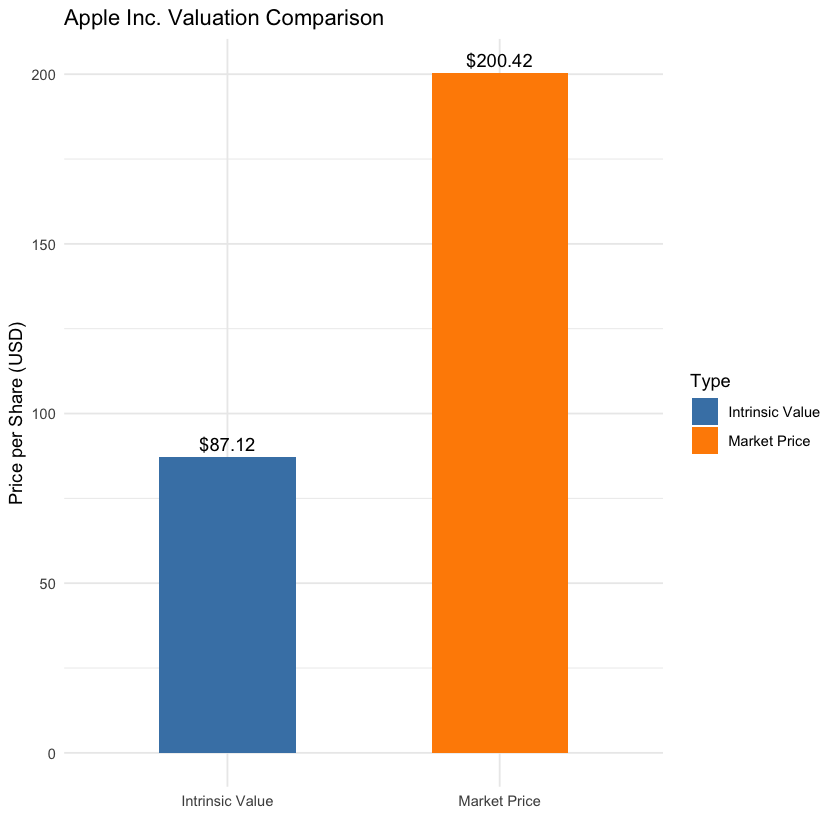

In [43]:
# R code to visualize the comparison
library(ggplot2)

# Data
valuation_data <- data.frame(
  Type = c("Intrinsic Value", "Market Price"),
  Price = c(87.12, 200.42)
)

# Plot
ggplot(valuation_data, aes(x = Type, y = Price, fill = Type)) +
  geom_bar(stat = "identity", width = 0.5) +
  labs(title = "Apple Inc. Valuation Comparison",
       y = "Price per Share (USD)",
       x = "") +
  theme_minimal() +
  scale_fill_manual(values = c("steelblue", "darkorange")) +
  geom_text(aes(label = paste0("$", round(Price, 2))), vjust = -0.5)

Based on this DCF analysis using real financial data, Apple’s stock appears to be significantly overvalued compared to its intrinsic value. However, it’s essential to consider that DCF models are sensitive to:
- Market Sentiment: Investor optimism, brand strength, and future growth prospects can drive stock prices above intrinsic values.
- Assumptions in DCF: The DCF model relies on projections and assumptions (e.g., growth rates, discount rates) that may not capture all market dynamics.
